# **CO₂ Emissions Data: QA & Cleaning Pipeline**

**Focus:** Southeast Asia CO₂ Analysis | Indonesia

**Dataset:** Our World in Data Global CO₂ Emissions (`owid-co2-data`)  

**Purpose:** Document and reproduce all data quality checks applied to the OWID global CO₂ dataset before analysis. Originally cleaned in BigQuery and Power BI during a bootcamp sprint; this notebook makes every step explicit, reproducible, and auditable.

<br>

**QA checks in this notebook:**

| # | Check | What it tests |
|---|---|---|
| 1 | Schema validation | Required columns present, correct data types |
| 2 | Completeness | Null counts and % across key reporting columns |
| 3 | Duplicates | Country-year uniqueness across 50K+ rows |
| 4 | Aggregated regions | Rows without ISO codes (not real countries) |
| 5 | Range check | CO₂ values must be ≥ 0 (physically impossible otherwise) |
| 6 | Outlier detection | Extreme year-on-year growth rates (> 500%) |
| 7 | Country focus | Indonesia-specific completeness and modern-era validation |
| 8 | Final clean | Scope to analysis period, select reporting columns, export |

<br>

**Output:** `indonesia-co2-cleaned.csv` — 135 rows × 25 columns (Indonesia, 1889–2023)


##**Setup**

In [ ]:
# @title
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from datetime import datetime
import os
import warnings
warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────
FOCUS_COUNTRY = "Indonesia"

CO2_COLS = ["co2", "coal_co2", "oil_co2", "gas_co2", "cement_co2", "flaring_co2"]
KEY_REPORTING_COLS = ["co2", "coal_co2", "oil_co2", "gas_co2",
                      "cement_co2", "co2_per_capita", "population", "gdp"]
OUTLIER_THRESHOLD = 500  # % YoY growth flagged as extreme

os.makedirs("../outputs", exist_ok=True)

# ── QA logging ─────────────────────────────────────────────────────────────
issues = []

def log(check_id, check_name, column, severity, finding, action, affected_rows=0):
    issues.append({
        "check_id"      : check_id,
        "check_name"    : check_name,
        "column"        : column,
        "severity"      : severity,
        "finding"       : finding,
        "action_taken"  : action,
        "affected_rows" : affected_rows,
        "timestamp"     : datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    })
    icon = {"CRITICAL": "❌", "WARNING": "⚠️", "INFO": "ℹ️"}.get(severity, "  ")
    print(f"  {icon}  [{check_id}] {finding}")

print("Setup complete")

Setup complete


## **Load Raw Data**

The Our World in Data CO₂ dataset covers **255 countries and regions** from 1750 to 2023 across **79 variables**, everything from per-capita emissions to land-use-change CO₂. At 50,000+ rows it requires careful filtering before analysis.


In [ ]:
# @title
from google.colab import files
uploaded = files.upload()

Saving owid-co2-raw.csv to owid-co2-raw (4).csv


In [ ]:
# @title
df = pd.read_csv("owid-co2-raw.csv")

print(f'Raw shape: {df.shape}')
df.head(3)

Raw shape: (50191, 79)


,Country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1750,AFG,2802560.0,NaN,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## **Check 1: Schema Validation**

Before doing anything else, confirm the required columns exist and are correctly typed. A missing column here would silently break every downstream calculation.


In [ ]:
# @title
required_cols = ["Country", "year", "iso_code", "population",
                 "gdp", "co2", "coal_co2", "oil_co2", "gas_co2",
                 "cement_co2", "flaring_co2", "co2_per_capita"]

missing_cols = [c for c in required_cols if c not in df.columns]

if missing_cols:
    log("QA-01a", "Schema validation", str(missing_cols), "CRITICAL",
        f"{len(missing_cols)} required columns missing", "Halt — cannot proceed")
    raise ValueError(f"Missing columns: {missing_cols}")
else:
    log("QA-01a", "Schema validation", "all required columns", "INFO",
        f"All {len(required_cols)} required columns present ({len(df.columns)} total)",
        "No action needed")

# Check year dtype
if df["year"].dtype not in [np.int64, np.int32]:
    log("QA-01b", "Year dtype", "year", "WARNING",
        f"year dtype is {df['year'].dtype}, expected int", "Cast to int")
    df["year"] = df["year"].astype(int)
else:
    log("QA-01b", "Year dtype", "year", "INFO",
        f"Correct dtype: {df['year'].dtype}", "No action needed")

# Show dtypes for key columns
df[required_cols].dtypes.to_frame("dtype").T

  ℹ️  [QA-01a] All 12 required columns present (79 total)
  ℹ️  [QA-01b] Correct dtype: int64


,Country,year,iso_code,population,gdp,co2,coal_co2,oil_co2,gas_co2,cement_co2,flaring_co2,co2_per_capita
dtype,object,int64,object,float64,float64,float64,float64,float64,float64,float64,float64,float64


---
## **Check 2: Completeness (Global Dataset)**

High null rates are **expected** in a dataset spanning 1750–2023 because coal emissions weren't recorded before the industrial era. The goal here is to document what's missing and why.

In [ ]:
# @title
null_summary = []
for col in KEY_REPORTING_COLS:
    null_n   = df[col].isna().sum()
    null_pct = null_n / len(df) * 100
    severity = "CRITICAL" if null_pct > 80 else "WARNING" if null_pct > 20 else "INFO"
    note = "Historical gap: Pre-industrial era" if null_pct > 50 else "Flag for reporting"
    null_summary.append({"column": col, "null_count": null_n,
                         "null_pct": round(null_pct, 1), "severity": severity, "note": note})
    log("QA-02", "Completeness", col, severity,
        f"{null_n:,} nulls ({null_pct:.1f}%)", note, null_n)

summary_df = pd.DataFrame(null_summary)
display(summary_df)

  ⚠️  [QA-02] 21,054 nulls (41.9%)
  ⚠️  [QA-02] 28,436 nulls (56.7%)
  ⚠️  [QA-02] 24,973 nulls (49.8%)
  ⚠️  [QA-02] 32,177 nulls (64.1%)
  ⚠️  [QA-02] 21,328 nulls (42.5%)
  ⚠️  [QA-02] 24,009 nulls (47.8%)
  ℹ️  [QA-02] 9,172 nulls (18.3%)
  ⚠️  [QA-02] 34,940 nulls (69.6%)


,column,null_count,null_pct,severity,note
0,co2,21054,41.9,WARNING,Flag for reporting
1,coal_co2,28436,56.7,WARNING,Historical gap: Pre-industrial era
2,oil_co2,24973,49.8,WARNING,Flag for reporting
3,gas_co2,32177,64.1,WARNING,Historical gap: Pre-industrial era
4,cement_co2,21328,42.5,WARNING,Flag for reporting
5,co2_per_capita,24009,47.8,WARNING,Flag for reporting
6,population,9172,18.3,INFO,Flag for reporting
7,gdp,34940,69.6,WARNING,Historical gap: Pre-industrial era


---
## **Check 3: Duplicate Country-Year Pairs**

Each country-year combination should appear exactly once. Duplicates would skew any aggregate or time-series calculation.


In [ ]:
# @title
dup_n = df.duplicated(subset=["Country", "year"]).sum()

if dup_n > 0:
    log("QA-03", "Duplicates", "Country + year", "CRITICAL",
        f"{dup_n} duplicate country-year pairs found",
        "Remove duplicates, keep first occurrence", dup_n)
    df = df.drop_duplicates(subset=["Country", "year"], keep="first")

    print(f"{dup_n} duplicates removed")

else:
    log(check_id="QA-03", check_name="Duplicates", column="Country + year", severity="INFO",
        finding="No duplicates found, all country-year pairs are unique", action="No action needed", affected_rows=0)

    print(f"No duplicate country-year pairs found across {len(df):,} rows")

  ℹ️  [QA-03] No duplicates found, all country-year pairs are unique
No duplicate country-year pairs found across 50,191 rows


---
## **Check 4: Aggregated Regions (No ISO Code)**

The dataset includes continental and income-group aggregates alongside real countries: rows like `"Africa"`, `"World"`, and `"High-income countries"`. These have no ISO code.

Including them in country-level analysis would cause double-counting and distort per-country comparisons.


In [ ]:
# @title
agg_rows  = df[df["iso_code"].isna()]
agg_names = sorted(agg_rows["Country"].unique().tolist())

log("QA-04a", "Aggregated regions", "iso_code", "WARNING",
    f"{len(agg_rows):,} rows are regional aggregates ({len(agg_names)} distinct entities)",
    "Excluded from country-level analysis; retained in raw file",
    len(agg_rows))

print(f"Aggregated entities found ({len(agg_names)}):")
for name in agg_names:
    print(f"  · {name}")

  ⚠️  [QA-04a] 7,929 rows are regional aggregates (37 distinct entities)
Aggregated entities found (37):
  · Africa
  · Africa (GCP)
  · Asia
  · Asia (GCP)
  · Asia (excl. China and India)
  · Central America (GCP)
  · Europe
  · Europe (GCP)
  · Europe (excl. EU-27)
  · Europe (excl. EU-28)
  · European Union (27)
  · European Union (28)
  · High-income countries
  · International aviation
  · International shipping
  · International transport
  · Kosovo
  · Kuwaiti Oil Fires
  · Kuwaiti Oil Fires (GCP)
  · Least developed countries (Jones et al.)
  · Low-income countries
  · Lower-middle-income countries
  · Middle East (GCP)
  · Non-OECD (GCP)
  · North America
  · North America (GCP)
  · North America (excl. USA)
  · OECD (GCP)
  · OECD (Jones et al.)
  · Oceania
  · Oceania (GCP)
  · Ryukyu Islands
  · Ryukyu Islands (GCP)
  · South America
  · South America (GCP)
  · Upper-middle-income countries
  · World


In [ ]:
# @title
# Filter to country-only data
df_countries = df[df["iso_code"].notna()].copy()

log("QA-04b", "Filter: countries only", "iso_code", "INFO",
    f"Retained {len(df_countries):,} rows after removing aggregates",
    "Used for country-level analysis", 0)

print(f"\nBefore filter: {len(df):,} rows")
print(f"After filter:  {len(df_countries):,} rows")
print(f"Removed:       {len(df) - len(df_countries):,} aggregate rows")

  ℹ️  [QA-04b] Retained 42,262 rows after removing aggregates

Before filter: 50,191 rows
After filter:  42,262 rows
Removed:       7,929 aggregate rows


---
## **Check 5: Range Check for Negative CO₂ Values**

CO₂ emissions cannot be negative, it is physically impossible. Any negative value would indicate a data entry error or a unit conversion mistake and would need to be investigated before analysis.


In [ ]:
# @title
range_results = []
for col in CO2_COLS:
    neg_n = (df_countries[col] < 0).sum()
    severity = "CRITICAL" if neg_n > 0 else "INFO"
    finding  = f"{neg_n} negative values (physically impossible)" if neg_n > 0                else "No negative values — range check passed"
    action   = "Flag for source verification" if neg_n > 0 else "No action needed"
    log("QA-05", "Negative CO₂", col, severity, finding, action, neg_n)
    range_results.append({"column": col, "negative_count": neg_n, "status": "FAIL" if neg_n else "PASS"})

pd.DataFrame(range_results)

  ℹ️  [QA-05] No negative values — range check passed
  ℹ️  [QA-05] No negative values — range check passed
  ℹ️  [QA-05] No negative values — range check passed
  ℹ️  [QA-05] No negative values — range check passed
  ℹ️  [QA-05] No negative values — range check passed
  ℹ️  [QA-05] No negative values — range check passed


,column,negative_count,status
0,co2,0,PASS
1,coal_co2,0,PASS
2,oil_co2,0,PASS
3,gas_co2,0,PASS
4,cement_co2,0,PASS
5,flaring_co2,0,PASS


---
## **Check 6: Outlier Detection for Year-on-Year Growth Rate**

When a country starts from near-zero emissions and records its first significant measurement, the percentage growth can be astronomically high (e.g. 180,000%). These are mathematically valid but need to be flagged so they don't distort rolling averages or trend analysis.


```
Threshold: |YoY growth| > 500% is flagged as extreme.
```



In [ ]:
# @title
extreme = df_countries[df_countries["co2_growth_prct"].abs() > OUTLIER_THRESHOLD].copy()

log("QA-06", "YoY growth outliers", "co2_growth_prct", "WARNING",
    f"{len(extreme)} records with |growth| > {OUTLIER_THRESHOLD}% "
    f"(max: {df_countries['co2_growth_prct'].max():.0f}%, "
    f"min: {df_countries['co2_growth_prct'].min():.0f}%)",
    "Flagged with outlier_yoy_growth=True; not removed — valid for early industrialisation",
    len(extreme))

# Add outlier flag
df_countries = df_countries.copy()
df_countries["outlier_yoy_growth"] = df_countries["co2_growth_prct"].abs() > OUTLIER_THRESHOLD

print(f"Records flagged as extreme YoY outliers: {len(extreme):,}")
print(f"\nTop 5 most extreme growth rates:")
display(extreme[["Country", "year", "co2", "co2_growth_prct"]]
        .sort_values("co2_growth_prct", ascending=False)
        .head(5)
        .reset_index(drop=True))

  ⚠️  [QA-06] 117 records with |growth| > 500% (max: 180870%, min: -100%)
Records flagged as extreme YoY outliers: 117

Top 5 most extreme growth rates:


,Country,year,co2,co2_growth_prct
0,Paraguay,1920,0.018,180870.000
1,Haiti,1950,0.114,147561.031
2,Haiti,1923,0.007,91400.000
3,Costa Rica,1950,0.286,74814.664
4,El Salvador,1950,0.268,70018.844


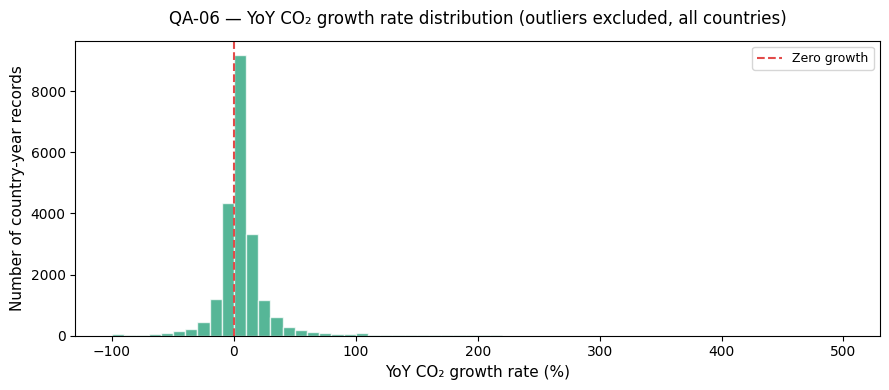

Chart saved → outputs/qa06_growth_distribution.png


In [ ]:
# @title
# Distribution of YoY growth rates (non-outlier range)
fig, ax = plt.subplots(figsize=(9, 4))
non_extreme = df_countries[
    (df_countries["co2_growth_prct"].abs() <= OUTLIER_THRESHOLD) &
    (df_countries["co2_growth_prct"].notna())
]

ax.hist(non_extreme["co2_growth_prct"], bins=60, color="#1D9E75", alpha=0.75, edgecolor="white")
ax.axvline(0, color="#E24B4A", linewidth=1.5, linestyle="--", label="Zero growth")
ax.set_xlabel("YoY CO₂ growth rate (%)", fontsize=11)
ax.set_ylabel("Number of country-year records", fontsize=11)
ax.set_title("QA-06 — YoY CO₂ growth rate distribution (outliers excluded, all countries)",
             fontsize=12, pad=12)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("../outputs/qa06_growth_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved → outputs/qa06_growth_distribution.png")

---
## **Check 7: Indonesia Country-Specific QA**

Now that the global dataset is validated, we zoom into Indonesia, the focus country for this analysis. We run two sub-checks:

* Null pattern for key columns — where are the gaps and why?
* Modern-era completeness check (2000–2023) — the analysis period must have no gaps



In [ ]:
# @title
df_indo = df_countries[df_countries["Country"] == FOCUS_COUNTRY].copy()

if len(df_indo) == 0:
    raise ValueError(f"'{FOCUS_COUNTRY}' not found in dataset")

log("QA-07a", "Country filter", "Country", "INFO",
    f"{len(df_indo)} rows for {FOCUS_COUNTRY} ({df_indo['year'].min()}–{df_indo['year'].max()})",
    "Extracted for focused analysis", 0)

print(f"Indonesia rows : {len(df_indo)}")
print(f"Year range     : {df_indo['year'].min()} – {df_indo['year'].max()}")
df_indo[["year"] + KEY_REPORTING_COLS].head(5)

  ℹ️  [QA-07a] 174 rows for Indonesia (1850–2023)
Indonesia rows : 174
Year range     : 1850 – 2023


,year,co2,coal_co2,oil_co2,gas_co2,cement_co2,co2_per_capita,population,gdp
21659,1850,NaN,NaN,NaN,NaN,NaN,NaN,21979198.0,1.663535e+10
21660,1851,NaN,NaN,NaN,NaN,NaN,NaN,22178120.0,1.729279e+10
21661,1852,NaN,NaN,NaN,NaN,NaN,NaN,22382251.0,1.685810e+10
21662,1853,NaN,NaN,NaN,NaN,NaN,NaN,22591664.0,1.767151e+10
21663,1854,NaN,NaN,NaN,NaN,NaN,NaN,22806435.0,1.710595e+10


In [ ]:
# @title
# Completeness per column for Indonesia
indo_nulls = []
for col in KEY_REPORTING_COLS:
    null_n   = df_indo[col].isna().sum()
    null_pct = null_n / len(df_indo) * 100
    null_years = df_indo[df_indo[col].isna()]["year"]
    year_range = f"{null_years.min()}–{null_years.max()}" if len(null_years) > 0 else "—"
    severity   = "WARNING" if null_pct > 50 else "INFO"
    indo_nulls.append({"column": col, "null_count": null_n,
                       "null_pct": round(null_pct, 1), "year_range_of_nulls": year_range,
                       "severity": severity})
    if null_pct > 0:
        log("QA-07b", "Indonesia completeness", col, severity,
            f"{null_n} nulls ({null_pct:.1f}%) — years {year_range}",
            "Pre-modern gap; analysis scoped to data-available years", null_n)

display(pd.DataFrame(indo_nulls))

  ℹ️  [QA-07b] 39 nulls (22.4%) — years 1850–1888
  ℹ️  [QA-07b] 39 nulls (22.4%) — years 1850–1888
  ℹ️  [QA-07b] 39 nulls (22.4%) — years 1850–1888
  ℹ️  [QA-07b] 39 nulls (22.4%) — years 1850–1888
  ℹ️  [QA-07b] 39 nulls (22.4%) — years 1850–1888
  ℹ️  [QA-07b] 39 nulls (22.4%) — years 1850–1888
  ℹ️  [QA-07b] 8 nulls (4.6%) — years 1942–2023


,column,null_count,null_pct,year_range_of_nulls,severity
0,co2,39,22.4,1850–1888,INFO
1,coal_co2,39,22.4,1850–1888,INFO
2,oil_co2,39,22.4,1850–1888,INFO
3,gas_co2,39,22.4,1850–1888,INFO
4,cement_co2,39,22.4,1850–1888,INFO
5,co2_per_capita,39,22.4,1850–1888,INFO
6,population,0,0.0,—,INFO
7,gdp,8,4.6,1942–2023,INFO


In [ ]:
# @title
# Modern era check: 2000-2023 must be gap-free
modern = df_indo[df_indo["year"] >= 2000]
modern_nulls = modern["co2"].isna().sum()

if modern_nulls > 0:
    log("QA-07c", "Indonesia modern era", "co2", "CRITICAL",
        f"{modern_nulls} null CO₂ values in 2000–2023 — unexpected gap",
        "Investigate — do not include in reporting", modern_nulls)
    print(f"❌  {modern_nulls} null CO₂ values found in 2000–2023")
else:
    log("QA-07c", "Indonesia modern era", "co2", "INFO",
        f"All {len(modern)} records (2000–2023) are complete", "No action needed", 0)
    print(f"✅  All {len(modern)} Indonesia records (2000–2023) have complete CO₂ data")

# Add data availability flag
df_indo = df_indo.copy()
df_indo["data_available"] = df_indo["co2"].notna()

  ℹ️  [QA-07c] All 24 records (2000–2023) are complete
✅  All 24 Indonesia records (2000–2023) have complete CO₂ data


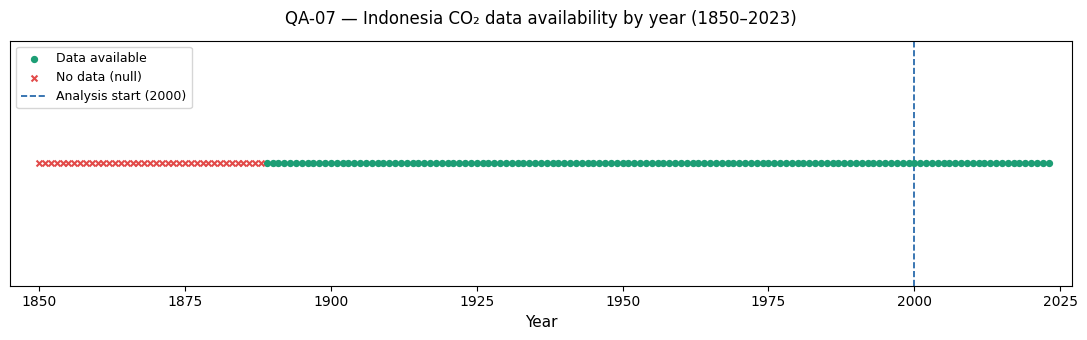

Chart saved → outputs/qa07_indonesia_coverage.png


In [ ]:
# @title
# Visualise Indonesia's CO2 data coverage
fig, ax = plt.subplots(figsize=(11, 3.5))

years_with_data    = df_indo[df_indo["data_available"]]["year"]
years_without_data = df_indo[~df_indo["data_available"]]["year"]

ax.scatter(years_with_data,    [1]*len(years_with_data),
           color="#1D9E75", s=18, label="Data available", zorder=3)
ax.scatter(years_without_data, [1]*len(years_without_data),
           color="#E24B4A", s=18, marker="x", label="No data (null)", zorder=3)

ax.axvline(2000, color="#185FA5", linewidth=1.2, linestyle="--", label="Analysis start (2000)")
ax.set_yticks([])
ax.set_xlabel("Year", fontsize=11)
ax.set_title("QA-07 — Indonesia CO₂ data availability by year (1850–2023)", fontsize=12, pad=12)
ax.legend(fontsize=9)
ax.set_xlim(1845, 2027)
plt.tight_layout()
plt.savefig("../outputs/qa07_indonesia_coverage.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved → outputs/qa07_indonesia_coverage.png")

---
## **Check 8: Finalize and Export Cleaned Dataset**

Scope the dataset to:
- **Rows:** Only years where CO₂ data is available (1889–2023)
- **Columns:** 25 core reporting columns relevant to the Indonesia analysis


In [ ]:
# @title
KEEP_COLS = [
    "Country", "year", "iso_code", "population", "gdp",
    "co2", "co2_growth_abs", "co2_growth_prct",
    "coal_co2", "oil_co2", "gas_co2", "cement_co2", "flaring_co2",
    "co2_per_capita", "co2_per_gdp",
    "co2_including_luc", "land_use_change_co2",
    "primary_energy_consumption", "energy_per_capita",
    "share_global_co2", "share_global_coal_co2",
    "cumulative_co2", "cumulative_coal_co2",
    "outlier_yoy_growth", "data_available"
]
KEEP_COLS = [c for c in KEEP_COLS if c in df_indo.columns]

df_indo_clean = df_indo[df_indo["data_available"]][KEEP_COLS].copy()

log("QA-08", "Final cleaned dataset", "all columns", "INFO",
    f"{len(df_indo_clean)} rows × {len(df_indo_clean.columns)} columns retained",
    f"Saved to {CLEAN_PATH}", 0)

print(f"Cleaned dataset: {len(df_indo_clean)} rows × {len(df_indo_clean.columns)} columns")
print(f"Year range     : {df_indo_clean['year'].min()} – {df_indo_clean['year'].max()}")
df_indo_clean.tail(5)

  ℹ️  [QA-08] 135 rows × 25 columns retained
Cleaned dataset: 135 rows × 25 columns
Year range     : 1889 – 2023


,Country,year,iso_code,population,gdp,co2,co2_growth_abs,co2_growth_prct,coal_co2,oil_co2,...,co2_including_luc,land_use_change_co2,primary_energy_consumption,energy_per_capita,share_global_co2,share_global_coal_co2,cumulative_co2,cumulative_coal_co2,outlier_yoy_growth,data_available
21828,Indonesia,2019,IDN,272489379.0,3.272568e+12,653.792,59.690,10.047,315.401,216.541,...,1550.346,896.554,2299.630,8530.325,1.762,2.146,13764.208,3436.177,False,True
21829,Indonesia,2020,IDN,274814864.0,3.204973e+12,608.223,-45.568,-6.970,300.518,196.666,...,1113.463,505.240,2163.753,7959.130,1.732,2.106,14372.431,3736.695,False,True
21830,Indonesia,2021,IDN,276758056.0,3.323655e+12,619.622,11.399,1.874,303.154,202.298,...,1055.700,436.078,2214.053,8087.771,1.675,2.003,14992.053,4039.848,False,True
21831,Indonesia,2022,IDN,278830529.0,3.500093e+12,737.073,117.450,18.955,404.573,216.563,...,1193.859,456.786,2791.422,10132.153,1.976,2.664,15729.126,4444.421,False,True
21832,Indonesia,2023,IDN,281190068.0,NaN,733.224,-3.849,-0.522,399.051,215.932,...,1288.977,555.753,2807.733,10116.714,1.940,2.591,16462.350,4843.472,False,True


In [ ]:
# @title
# Save outputs
df.to_csv('indonesia-co2-cleaned.csv', index=False)
files.download('indonesia-co2-cleaned.csv')

print('Saved: indonesia-co2-cleaned.csv')
print(f'Shape: {df.shape}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved: indonesia-co2-cleaned.csv
Shape: (50191, 79)


---
## **QA Summary**

Overview of all checks run, with severity breakdown and the full log table.


In [ ]:
# @title
log_df = pd.DataFrame(issues)

counts  = log_df["severity"].value_counts()
critical = counts.get("CRITICAL", 0)
warning  = counts.get("WARNING",  0)
info     = counts.get("INFO",     0)

print("=" * 55)
print("  QA PIPELINE COMPLETE")
print("=" * 55)
print(f"  ❌  CRITICAL : {critical}")
print(f"  ⚠️   WARNING  : {warning}")
print(f"  ℹ️   INFO     : {info}")
print(f"  {'─'*35}")
print(f"  Total checks run  : {len(log_df)}")
print(f"  Cleaned rows      : {len(df_indo_clean)}")
print(f"  Year range        : {df_indo_clean['year'].min()}–{df_indo_clean['year'].max()}")
print(f"  Output columns    : {len(df_indo_clean.columns)}")
print("=" * 55)

  QA PIPELINE COMPLETE
  ❌  CRITICAL : 0
  ⚠️   WARNING  : 9
  ℹ️   INFO     : 21
  ───────────────────────────────────
  Total checks run  : 30
  Cleaned rows      : 135
  Year range        : 1889–2023
  Output columns    : 25


In [ ]:
# @title
# Full QA log table
display(log_df[["check_id","check_name","column","severity","finding","action_taken","affected_rows"]])

,check_id,check_name,column,severity,finding,action_taken,affected_rows
0,QA-01a,Schema validation,all required columns,INFO,All 12 required columns present (79 total),No action needed,0
1,QA-01b,Year dtype,year,INFO,Correct dtype: int64,No action needed,0
2,QA-02,Completeness,co2,WARNING,"21,054 nulls (41.9%)",Flag for reporting,21054
3,QA-02,Completeness,coal_co2,WARNING,"28,436 nulls (56.7%)",Historical gap: Pre-industrial era,28436
4,QA-02,Completeness,oil_co2,WARNING,"24,973 nulls (49.8%)",Flag for reporting,24973
5,QA-02,Completeness,gas_co2,WARNING,"32,177 nulls (64.1%)",Historical gap: Pre-industrial era,32177
6,QA-02,Completeness,cement_co2,WARNING,"21,328 nulls (42.5%)",Flag for reporting,21328
7,QA-02,Completeness,co2_per_capita,WARNING,"24,009 nulls (47.8%)",Flag for reporting,24009
8,QA-02,Completeness,population,INFO,"9,172 nulls (18.3%)",Flag for reporting,9172
9,QA-02,Completeness,gdp,WARNING,"34,940 nulls (69.6%)",Historical gap: Pre-industrial era,34940


---
## **Notes and Decisions**

| Decision | Rationale |
|---|---|
| Aggregated regions excluded | Country-level analysis only; aggregates would cause double-counting |
| Pre-1889 rows excluded | No CO₂ data available for Indonesia before 1889 |
| GDP nulls (1942–1949) retained as null | WWII-era gap; imputation would introduce inaccuracy |
| Flaring nulls retained as null | Flaring data genuinely unavailable pre-2010 |
| Outliers flagged, not removed | Extreme YoY % values are valid for near-zero base years |
| Analysis scoped to 1889–2023 | Ensures all core CO₂ columns are complete |

---
<br>

*This notebook was developed as part of a data analytics bootcamp sprint. The original analysis was performed in PowerQuery and Power BI; this notebook makes the data quality process reproducible and auditable.*
